In [170]:
import pandas as pd
from rdkit.Chem import Descriptors, MolFromSmiles
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

In [171]:
def calculate_descriptors(smiles):
    mol = MolFromSmiles(str(smiles))
    return Descriptors.CalcMolDescriptors(mol)

df = pd.read_excel('Baza_FR_bez_jonów.xlsx')
descriptors_list = [calculate_descriptors(smiles) for smiles in df['smiles']]

result_df = pd.DataFrame(descriptors_list)
result_df.insert(0, 'CAS', df['cas'])
result_df.to_excel('deskryptory_z_cas.xlsx', index=False)

Deskryptory 2D dla uprzednio przygotowanych identyfikatorów cas zostały obliczone za pomocą biblioteki RDKit. Z pliku zawierającego deskryptory zostały usunięte wiersze z powtarzającymi się zwiazkami oraz mieszaniny jonów.

Do hierarchicznej analizy skupień wybraliśmy trzy metody: ward likage z metryką euclidean, average likage z metryką manhattan, complete linkage z metryką Czebyshewa.

In [172]:
def klasy_chemiczne(klasy_fr):
    klasy = pd.read_excel(klasy_fr)
    slownik_klas = dict(zip(klasy['cas'], klasy['klasa_chemiczna']))

    kolory_klas = {
        'Bromomethanes':'blue',
        'Organochlorine':'red',
        'Bisphenol':'blueviolet',
        'Polybrominated diphenyl ethers (PBDE)':'green',
        'Diphenyl ether':'brown',
        'Phenol':'orange',
        'Organophosphate':'deeppink',
        'Polychlorinated biphenyl (PCB)':'teal'
    }

    return slownik_klas, kolory_klas


def linkage_matrix(dane, metryka, metoda):
    scaler = StandardScaler()
    dane_znormalizowane = scaler.fit_transform(dane)

    odleglosci = pdist(dane_znormalizowane, metric=metryka)
    x = linkage(odleglosci, method=metoda)
    return x


def wykres(linkage_matrix,metryka,metoda,slownik_klas,kolory_klas,cas):
        plt.figure(figsize=(14, 7))
        R = dendrogram(linkage_matrix, labels=cas, leaf_rotation=90)
        for tick in plt.gca().get_xticklabels():
            cas_numer = tick.get_text() 
            klasa = slownik_klas.get(cas_numer, 'Unknown')
            kolor = kolory_klas.get(klasa)
            tick.set_color(kolor)
        plt.legend(handles=[Patch(color=kolor, label=klasa) for klasa, kolor in kolory_klas.items()], title='Klasy chemiczne', bbox_to_anchor=(1.32, 1))
        plt.title(f'HCA, {metoda} linkage, {metryka} metric')
        plt.xlabel('CAS')
        plt.ylabel(f'odległość {metryka}')
        plt.show()

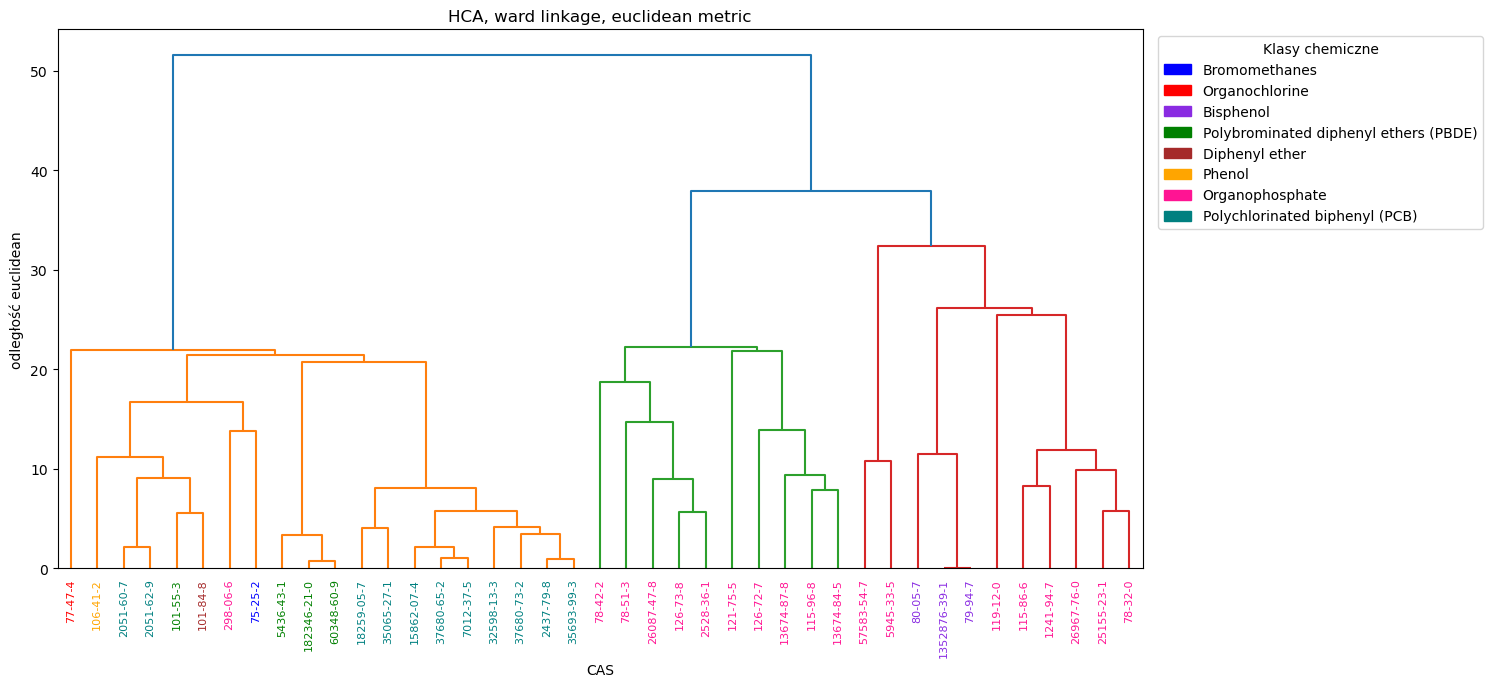

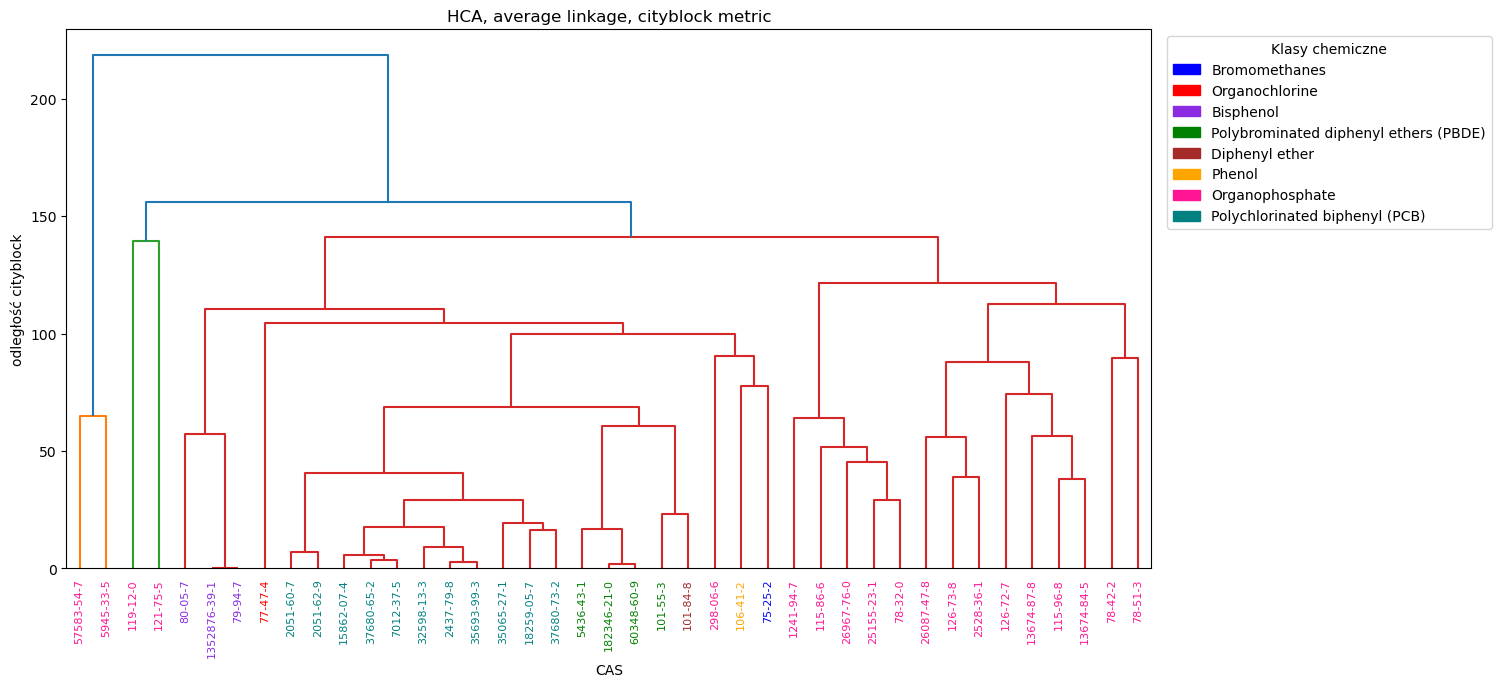

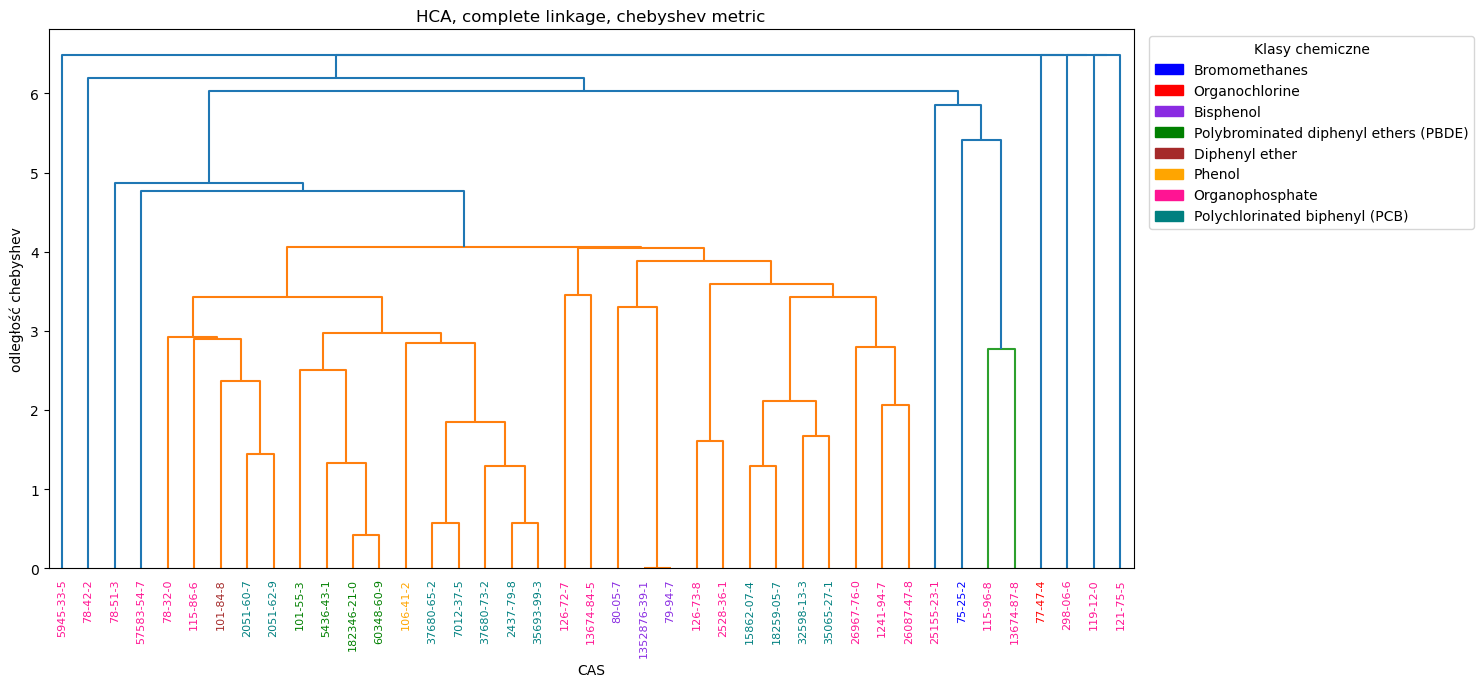

In [173]:
if __name__ == '__main__':  
    df = pd.read_excel('deskryptory_z_cas_2.xlsx', dtype={0: str})
    cas = df.iloc[:, 0].values
    dane = df.iloc[:, 1:].values

    klasy_fr='Klasy_FR.xlsx'
    slownik_klas,kolory_klas = klasy_chemiczne(klasy_fr)

    metryka='euclidean'
    metoda='ward'
    x=linkage_matrix(dane,metryka,metoda)
    wykres(x,metryka,metoda,slownik_klas,kolory_klas,cas)

    metryka='cityblock'
    metoda='average'
    x=linkage_matrix(dane,metryka,metoda)
    wykres(x,metryka,metoda,slownik_klas,kolory_klas,cas)

    metryka='chebyshev'
    metoda='complete'
    x=linkage_matrix(dane,metryka,metoda)
    wykres(x,metryka,metoda,slownik_klas,kolory_klas,cas)

    

ANALIZA WYNIKÓW

Wykresy przedstawiają wyniki hierarchicznej analizy skupień dla zbioru zwiazków zmniejszających palność. Zwiazki zostały podzielone na klasy chemiczne, pozwoliło to na porównanie klastrów powstałych w trakcie HCA z klasami pochodzącymi z literatury. Do analizy wykorzystaliśmy trzy różne kombinacje miar odległości i metod wiązania.

euclidean-ward

Produktem tej kombinacji jest czytelny podział, który lepiej od pozostałych odzwierciedla rzeczywiste klasy chemiczne zwiazków. Powstały trzy duże klastry. Klasy Organophosphatów, Bisphenoli oraz Polychlorinated biphenyli stworzyły duze skupienia z nielicznymi odstępstwami, co potwierdza ich podobieństwo.
 

manhattan-average

Druga kombinacja dała znacznie gorsze wyniki, powstały dwa dwuelementowe klastry oraz jeden zawierający wszystkie pozostałe związki. Na dendrogramie widać podobieństwo związków, jednak powstanie jednego dużego klastra utrudnia interpretacje. 


czybeszew-complete

Ta kombinacja dała najgorsze wyniki, na dendrogrami brakuje wyraźnie wyodrębionych grup. Występują związki które osiągają maksymalną odległość od pozostałych klastrów/związków i są dołączane na krańcach wykresu.

